# F1 Pit Stop Prediction — Training Framework

Binary classification: predict `PitNextLap` (whether the driver pits on the next lap).

Pipeline: load → EDA → preprocess → CV training → submission.

EDA lives in `eda.ipynb`. This notebook covers feature engineering, cross-validated training, and submission.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

import lightgbm as lgb

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_DIR = Path('.')

## 1. Load data

In [16]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'

print('train:', train.shape, '| test:', test.shape)
train.head()

train: (439140, 16) | test: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Feature engineering

In [ ]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Improved feature engineering for F1 pit-stop prediction.

    Philosophy:
    - Remove redundant/raw overlapping variables
    - Add interaction-based strategic features
    - Add nonlinear race-window behaviour
    - Preserve primitive variables for tree models
    - Avoid unstable exploding ratios
    """

    df = df.copy()

    # =========================================================
    # BASIC SAFE VARIABLES
    # =========================================================

    eps = 1e-6

    # Remaining race fraction
    df['RemainingRace'] = 1.0 - df['RaceProgress']

    # Mid-race pit-window tendency
    # Peaks near middle of race
    df['PitWindow'] = df['RaceProgress'] * (1 - df['RaceProgress'])

    # Late race binary
    df['IsLateRace'] = (df['RaceProgress'] > 0.7).astype(int)

    # =========================================================
    # TYRE DYNAMICS
    # =========================================================

    # Pace per tyre age
    df['LapTime_per_TyreLife'] = (
        df['LapTime (s)'] /
        (df['TyreLife'] + eps)
    )

    # Degradation rate per lap
    df['Deg_per_TyreLife'] = (
        df['Cumulative_Degradation'] /
        (df['TyreLife'] + eps)
    )

    # Total tyre stress
    df['TyreStress'] = (
        df['TyreLife'] *
        df['Cumulative_Degradation']
    )

    # Strategic urgency
    # Old degraded tyres + many laps remaining
    df['StrategicUrgency'] = (
        df['TyreLife'] *
        df['Cumulative_Degradation'] *
        df['RemainingRace']
    )

    # Tyre exhaustion factor
    df['TyreExhaustion'] = (
        (df['TyreLife'] ** 2) *
        df['RemainingRace']
    )

    # Tyre cliff detector
    # Old tyres + worsening pace
    df['TyreCliff'] = (
        df['TyreLife'] *
        df['LapTime_Delta']
    )

    # =========================================================
    # STRATEGY / POSITION FEATURES
    # =========================================================

    # Position pressure
    df['PositionPressure'] = (
        df['Position'] *
        df['RemainingRace']
    )

    # Recovery pressure
    # Losing positions while tyres degrade
    df['RecoveryPressure'] = (
        abs(df['Position_Change']) *
        df['Cumulative_Degradation']
    )

    # Compound-age interaction
    # First encode compound numerically
    compound_map = {
        'HARD': 1,
        'MEDIUM': 2,
        'SOFT': 3
    }

    df['CompoundCode'] = (
        df['Compound']
        .astype(str)
        .str.upper()
        .map(compound_map)
        .fillna(2)
    )

    df['CompoundTyreInteraction'] = (
        df['CompoundCode'] *
        df['TyreLife']
    )

    # =========================================================
    # OPTIONAL NONLINEAR STRATEGY FEATURE
    # =========================================================

    # More stable than previous exploding ratio
    df['StrategyPressure'] = (
        df['TyreStress'] *
        df['PitWindow']
    )

    return df


# =============================================================
# APPLY FEATURE ENGINEERING
# =============================================================

train_fe = add_features(train)
test_fe  = add_features(test)

# =============================================================
# CATEGORICAL FEATURES
# =============================================================

CAT_COLS = [
    'Driver',
    'Compound',
    'Race'
]

for c in CAT_COLS:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c]  = test_fe[c].astype('category')

# =============================================================
# DROP REDUNDANT / RAW FEATURES
# =============================================================

DROP_COLS = [
    ID_COL,
    TARGET,

    # Remove redundant lap normalization
    'LapNumber',

    # Remove engineered-overlap raw features
    # (optional: keep them if using boosting)
    # 'TyreLife',
    # 'Cumulative_Degradation',

    # Keep RaceProgress because nonlinear
    # transforms depend on it

    # Remove weak duplicated feature idea
    # (tree models don't benefit meaningfully)
]

# =============================================================
# FINAL FEATURE LIST
# =============================================================

FEATURES = [
    c for c in train_fe.columns
    if c not in DROP_COLS
]

print(f'{len(FEATURES)} features')
print(FEATURES)
"""H"""

27 features
['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'RemainingRace', 'PitWindow', 'IsLateRace', 'LapTime_per_TyreLife', 'Deg_per_TyreLife', 'TyreStress', 'StrategicUrgency', 'TyreExhaustion', 'TyreCliff', 'PositionPressure', 'RecoveryPressure', 'CompoundCode', 'CompoundTyreInteraction', 'StrategyPressure']


## 4. Cross-validation training

Group by `(Race, Year, Driver)` so the same stint doesn't leak across folds.

In [ ]:
X = train_fe.drop(columns=[c for c in DROP_COLS if c in train_fe.columns])
y = train_fe[TARGET]
groups = (train_fe['Race'].astype(str) + '_' + train_fe['Year'].astype(str) + '_' + train_fe['Driver'].astype(str))
X_test = test_fe.drop(columns=[c for c in DROP_COLS if c in test_fe.columns])

# num_threads=8 + force_row_wise=True are perf-only (see CLAUDE.md); without them, training is ~200x slower on this machine.
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': RANDOM_STATE,
    'num_threads': 8,
    'force_row_wise': True,
}

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(train_fe))
test_pred = np.zeros(len(test_fe))
feat_importance = pd.DataFrame(index=FEATURES)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
    X_tr, X_va = X.iloc[tr_idx][FEATURES], X.iloc[va_idx][FEATURES]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    X_te_f = X_test[FEATURES]

    dtr = lgb.Dataset(X_tr, y_tr, categorical_feature=CAT_COLS)
    dva = lgb.Dataset(X_va, y_va, categorical_feature=CAT_COLS)
    model = lgb.train(
        params, dtr,
        num_boost_round=3000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
    )
    oof[va_idx] = model.predict(X_va)
    test_pred += model.predict(X_te_f) / N_SPLITS
    feat_importance[f'fold{fold}'] = model.feature_importance(importance_type='gain')
    print(f'Fold {fold} AUC = {roc_auc_score(y_va, oof[va_idx]):.5f}')

print('\nOOF AUC :', roc_auc_score(y, oof))
print('OOF AP  :', average_precision_score(y, oof))
print('OOF LL  :', log_loss(y, oof))

Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.939473
[400]	valid_0's auc: 0.940721
[600]	valid_0's auc: 0.941083
[800]	valid_0's auc: 0.941529
Early stopping, best iteration is:
[815]	valid_0's auc: 0.941556
Fold 0 AUC = 0.94156
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.941217
[400]	valid_0's auc: 0.942244
[600]	valid_0's auc: 0.942731
[800]	valid_0's auc: 0.942924
Early stopping, best iteration is:
[749]	valid_0's auc: 0.942951
Fold 1 AUC = 0.94295
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940071
[400]	valid_0's auc: 0.941326
[600]	valid_0's auc: 0.941839
[800]	valid_0's auc: 0.94223
Early stopping, best iteration is:
[804]	valid_0's auc: 0.942253
Fold 2 AUC = 0.94225
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.940237
[400]	valid_0's auc: 0.941319
[600]	valid_0's auc: 0.941637
[800]	valid_0's auc: 0.941866
Early stopping,

## 5. Feature importance

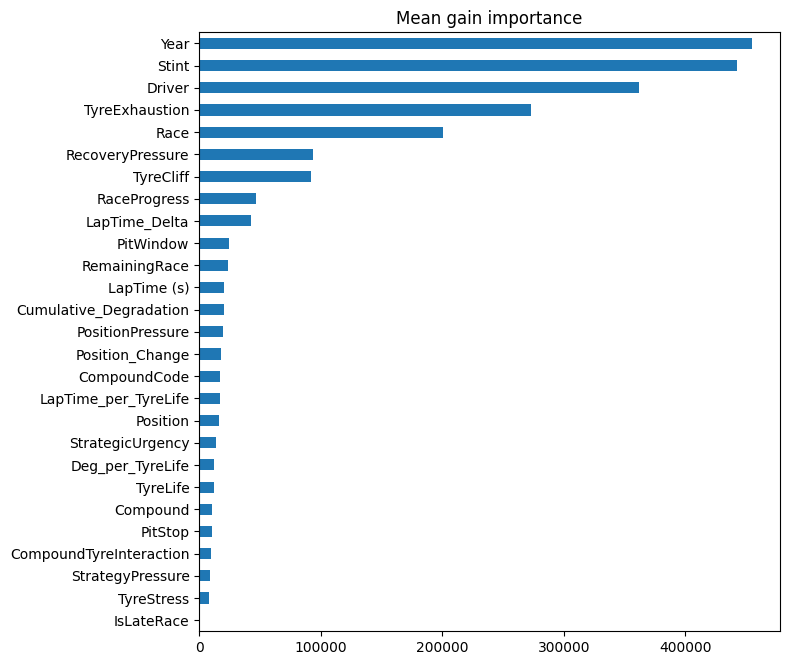

In [19]:
imp = feat_importance.mean(axis=1).sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(imp) * 0.25))); imp.plot.barh(); plt.title('Mean gain importance'); plt.tight_layout(); plt.show()

## 6. Submission

In [20]:
submission = sample_submission.copy()
submission[TARGET] = test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,PitNextLap
0,439140,0.003767
1,439141,0.002303
2,439142,0.003742
3,439143,0.149222
4,439144,0.823746
